In [2]:
import sys
sys.path.append("/opt/tiger/OpenFedLLM")
from utils import *
dataset = get_dataset("vicgalle/alpaca-gpt4")

In [3]:
print(len(dataset))

52002


In [4]:
print(type(dataset))

<class 'datasets.arrow_dataset.Dataset'>


查看 moe lora

In [4]:
from transformers import AutoModelForCausalLM
import torch
from peft import get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict

model = AutoModelForCausalLM.from_pretrained(
    "/mnt/bn/data-tns-live-llm/leon/datasets/Llama-2-7b-hf/",
    torch_dtype=torch.bfloat16,
    use_cache=False
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.80s/it]


In [5]:
from peft import LoraConfig
peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, peft_config)
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaSdpaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(i

In [6]:
model.save_pretrained("llama2_lora_adapter")

In [7]:
import xlora
model_created = xlora.add_xlora_to_model(
    model=model,
    xlora_config=xlora.xLoRAConfig(
        4096,
        base_model_id="/mnt/bn/data-tns-live-llm/leon/datasets/Llama-2-7b-hf/",
        xlora_depth=1,
        device=torch.device("cuda"),
        adapters={
            "adapter_1": "/mnt/bn/data-tns-live-llm/leon/OpenFedLLM/llama2_lora_adapter",
            "adapter_2": "/mnt/bn/data-tns-live-llm/leon/OpenFedLLM/llama2_lora_adapter",
        },
    ),
    verbose=True,
)

  0%|          | 0/2 [00:00<?, ?it/s]

/home/tiger/miniconda3/envs/llm/lib/python3.11/site-packages/peft/peft_model.py:599: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.adapter_1.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.adapter_1.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.adapter_1.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.adapter_1.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.q_proj.lora_A.adapter_1.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.q_proj.lora_B.adapter_1.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.v_proj.lora_A.adapter_1.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.v_proj.lora_B.adapter_1.weight', 'base_model.model.base_model.model.model.layers.2.self_attn.q_proj.lora_A.adapter_1.weight', 'base_m

Froze 384 adapters.
LoRA -> xLoRA complete: Swapped 64 LoRA layers (out of 1483 modules).


In [10]:
print(model_created.peft_config)

{'default': LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path='/mnt/bn/data-tns-live-llm/leon/datasets/Llama-2-7b-hf/', revision=None, inference_mode=False, r=32, target_modules={'q_proj', 'v_proj'}, exclude_modules=None, lora_alpha=64, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', loftq_config={}, eva_config=None, use_dora=False, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False), 'adapter_1': LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path='/mnt/bn/data-tns-live-llm/leon/datasets/Llama-2-7b-hf/', revision=None, inference_mode=True, r=32, target_modules={'q_proj', 'v_proj'}, exclude_modules=None, lora_alph

In [13]:
print(get_peft_model_state_dict(model_created,adapter_name="adapter_1").keys())

dict_keys(['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.q_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.q_proj.lora_B.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.v_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.1.self_attn.v_proj.lora_B.weight', 'base_model.model.base_model.model.model.layers.2.self_attn.q_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.2.self_attn.q_proj.lora_B.weight', 'base_model.model.base_model.model.model.layers.2.self_attn.v_proj.lora_A.weight', 'base_model.model.base_model.model.model.layers.2.self_attn.v_proj.lora_B.we

In [9]:
for name, parameters in model_created.named_parameters():
    print(f"{name}, :, {parameters.size()},{parameters.requires_grad}")
    # break

base_model.model.base_model.model.model.embed_tokens.weight, :, torch.Size([32000, 4096]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight, :, torch.Size([4096, 4096]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight, :, torch.Size([32, 4096]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.adapter_1.weight, :, torch.Size([32, 4096]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.adapter_2.weight, :, torch.Size([32, 4096]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight, :, torch.Size([4096, 32]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.adapter_1.weight, :, torch.Size([4096, 32]),False
base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.adapter_2.weight, :, torch.Size([4096, 32]),False
base_model.model.base_model.model.model.layers.0.se

In [3]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    lora_nums=8
)

In [4]:
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 136314880 || all params: 6874730496 || trainable%: 1.9828396193758226


In [9]:
print(type(model))
print(type(model.base_model))
print(model.base_model)

<class 'peft.peft_model.PeftModelForCausalLM'>
<class 'peft.tuners.lora.LoraModel'>
LoraModel(
  (model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(32000, 4096)
      (layers): ModuleList(
        (0-31): 32 x LlamaDecoderLayer(
          (self_attn): LlamaSdpaAttention(
            (q_proj): Linear(
              in_features=4096, out_features=4096, bias=False
              (lora_dropout): Dropout(p=0.05, inplace=False)
              (lora_route): Linear(in_features=4096, out_features=8, bias=False)
              (lora_A0): Linear(in_features=4096, out_features=32, bias=False)
              (lora_B0): Linear(in_features=32, out_features=4096, bias=False)
              (lora_A1): Linear(in_features=4096, out_features=32, bias=False)
              (lora_B1): Linear(in_features=32, out_features=4096, bias=False)
              (lora_A2): Linear(in_features=4096, out_features=32, bias=False)
              (lora_B2): Linear(in_features=32, out_features=4096,

In [11]:
for key, value in model.named_parameters():
    print(key)
    if "lora" in key:
        print(value.shape)
        break

base_model.model.model.embed_tokens.weight
base_model.model.model.layers.0.self_attn.q_proj.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_route.weight
torch.Size([8, 4096])


In [11]:
print(model.parameters())
print(model.named_parameters())

<generator object Module.parameters at 0x7f34896090e0>


TypeError: 'generator' object is not subscriptable

In [17]:
for name, parameters in model.named_parameters():
    print(f"{name}, :, {parameters.size()},{parameters.requires_grad}{parameters}")
    break

base_model.model.model.embed_tokens.weight, :, torch.Size([32000, 4096]),FalseParameter containing:
tensor([[ 1.2517e-06, -1.7881e-06, -4.3511e-06,  ...,  8.9407e-07,
         -6.5565e-06,  8.9407e-07],
        [ 1.8616e-03, -3.3722e-03,  3.9864e-04,  ..., -8.3008e-03,
          2.5787e-03, -3.9368e-03],
        [ 1.0986e-02,  9.8877e-03, -5.0964e-03,  ...,  2.5177e-03,
          7.7057e-04, -5.0049e-03],
        ...,
        [-1.3977e-02, -2.7313e-03, -1.9897e-02,  ..., -1.0437e-02,
          9.5825e-03, -1.8005e-03],
        [-1.0742e-02,  9.3384e-03,  1.2939e-02,  ..., -3.3203e-02,
         -1.6357e-02,  3.3875e-03],
        [-8.3008e-03, -4.0588e-03, -1.1063e-03,  ...,  3.4790e-03,
         -1.2939e-02,  3.1948e-05]], dtype=torch.bfloat16)


# 测试vllm 生成

In [4]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
import torch

In [5]:
tokenizer = AutoTokenizer.from_pretrained("/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache")
llm = LLM(model="/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache", tensor_parallel_size=1, dtype=torch.bfloat16, trust_remote_code=True, 
    enable_lora=False, max_model_len=2048, gpu_memory_utilization=0.8)
llm.pad_token = tokenizer.eos_token

INFO 12-10 16:22:48 config.py:350] This model supports multiple tasks: {'generate', 'embedding'}. Defaulting to 'generate'.
INFO 12-10 16:22:48 llm_engine.py:249] Initializing an LLM engine (v0.6.4.post1) with config: model='/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache', speculative_config=None, tokenizer='/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forw

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:02,  1.28it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:01<00:01,  1.05it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:03<00:01,  1.05s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:03<00:00,  1.22it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:03<00:00,  1.14it/s]



INFO 12-10 16:22:53 model_runner.py:1077] Loading model weights took 14.9595 GB
INFO 12-10 16:22:54 worker.py:232] Memory profiling results: total_gpu_memory=79.15GiB initial_memory_usage=15.47GiB peak_torch_memory=16.15GiB memory_usage_post_profile=15.50GiB non_torch_memory=0.54GiB kv_cache_size=46.64GiB gpu_memory_utilization=0.80
INFO 12-10 16:22:54 gpu_executor.py:113] # GPU blocks: 23878, # CPU blocks: 2048
INFO 12-10 16:22:54 gpu_executor.py:117] Maximum concurrency for 2048 tokens per request: 186.55x
INFO 12-10 16:22:56 model_runner.py:1400] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 12-10 16:22:56 model_runner.py:1404] If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory_utilization` or switching to eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.


In [9]:
sampling_params = SamplingParams(
    temperature=0.6,
    top_p=0.9,
    max_tokens=256
)
outputs = llm.generate(["Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat is the definition of the term \"sustainable development\"? \n\n### Response:"], sampling_params)
print(outputs[0].outputs[0].text)

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s, est. speed input: 41.96 toks/s, output: 81.71 toks/s]

Sustainable development is a concept that aims to meet the needs of the present without compromising the ability of future generations to meet their own needs. It is a balance between economic growth, social equity, and environmental protection. It is a long-term approach that considers the impact of human activities on the environment and seeks to find solutions that are both economically viable and environmentally sustainable.


# 测试unsloth inference加速的效果

In [1]:
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/M0",
    dtype = None,
    load_in_4bit=True
)

Unsloth: Patching Xformers to fix some performance issues.
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[2025-02-11 05:39:53,314] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/tiger/.pyenv/versions/3.11.2/lib/python3.11/site-packages/bytedmetrics/__init__.py:10: UserWarning: bytedmetrics is renamed to bytedance.metrics, please using `bytedance.metrics` instead of `bytedmetrics`
  warnings.warn("bytedmetrics is renamed to bytedance.metrics, please using `bytedance.metrics` instead of `bytedmetrics`")
/usr/bin/ld: cannot find -laio
collect2: error: ld returned 1 exit status
/usr/bin/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `dlvsym'
/usr/bin/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `dlopen'
/usr/bin/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `dlclose'
/usr/bin/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `dlerror'
/usr/bin/ld: /usr/local/cuda/lib64/libcufile.so: undefined reference to `dlsym'
collect2: error: ld returned 1 exit status


INFO 02-11 05:39:54 __init__.py:190] Automatically detected platform cuda.
==((====))==  Unsloth 2025.2.4: Fast Llama patching. Transformers: 4.48.3.
   \\   /|    GPU: NVIDIA A100-SXM4-80GB. Max memory: 79.151 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.28.post3. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2025.2.4 patched 32 layers with 32 QKV layers, 32 O layers and 0 MLP layers.


In [4]:
print(type(model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
from unsloth import is_bfloat16_supported
import torch
from unsloth import FastLanguageModel
max_seq_length = 2048 # Can increase for longer reasoning traces
lora_rank = 32 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/fedavg_c3s3_i-1_b8a1_l2048_r32a64_ranknet0/checkpoint-25_merged",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = True, # Enable vLLM fast inference
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.4, # Reduce if out of memory
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
    ], # Remove QKVO if out of memory
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # Enable long context finetuning
    random_state = 3407,
)

In [ ]:
model1, tokenizer1 = FastLanguageModel.from_pretrained(
    model_name = "/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/M0_merged",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = True, # Enable vLLM fast inference
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.4, # Reduce if out of memory
)

model1 = FastLanguageModel.get_peft_model(
    model1,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
    ], # Remove QKVO if out of memory
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # Enable long context finetuning
    random_state = 3407,
)

In [13]:
import copy 
from peft import get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict, prepare_model_for_kbit_training

global_dict = copy.deepcopy(get_peft_model_state_dict(model))
print(global_dict.keys())
dict1 = copy.deepcopy(get_peft_model_state_dict(model1))
print(dict1.keys())
set_peft_model_state_dict(model1, global_dict)

dict_keys(['base_model.model.model.layers.0.self_attn.q_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_A.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_B.weight', 'base_model.model.model.layers.1.self_attn.v_proj.lora_A.weight', 'base_model.model.model.layers.1.self_attn.v_proj.lora_B.weight', 'base_model.model.model.layers.1.self_attn.o_proj.lora_A.weight',

_IncompatibleKeys(missing_keys=['base_model.model.model.embed_tokens.weight', 'base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight', 'base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight', 'base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight', 'base_model.model.model.layers.0.self_attn.o_proj.base_layer.weight', 'base_model.model.model.layers.0.mlp.gate_proj.weight', 'base_model.model.model.layers.0.mlp.up_proj.weight', 'base_model.model.model.layers.0.mlp.down_proj.weight', 'base_model.model.model.layers.0.input_layernorm.weight', 'base_model.model.model.layers.0.post_attention_layernorm.weight', 'base_model.model.model.layers.1.self_attn.q_proj.base_layer.weight', 'base_model.model.model.layers.1.self_attn.k_proj.base_layer.weight', 'base_model.model.model.layers.1.self_attn.v_proj.base_layer.weight', 'base_model.model.model.layers.1.self_attn.o_proj.base_layer.weight', 'base_model.model.model.layers.1.mlp.gate_proj.weight', 'base_model.mod

In [14]:
model.save_lora("saved_lora")

In [14]:
full_input = tokenizer("hello world", return_tensors="pt")
full_input_ids = full_input["input_ids"].to(model.device)

In [18]:
from vllm import SamplingParams
sampling_params = SamplingParams(
    temperature = 0.8,
    top_p = 0.95,
    max_tokens = 256,
)
output = model(full_input_ids)

output.logits

tensor([[[ 4.8438,  6.2812,  9.8125,  ..., -3.1562, -3.1562, -3.1562],
         [12.9375,  3.1406,  4.3750,  ..., -6.6875, -6.6875, -6.6875],
         [12.0000,  6.0625,  5.5000,  ..., -8.9375, -8.9375, -8.9375]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [ ]:
from vllm import LLM, SamplingParams

# 初始化模型
llm = LLM(model="your-model-name")

# 设置生成参数，启用对数概率输出
sampling_params = SamplingParams(temperature=0, max_tokens=50, output_log_probs=True)

# 生成文本
prompt = "Once upon a time"
outputs = llm.generate(prompt, sampling_params)

# 获取生成结果
for output in outputs:
    generated_text = output.outputs[0].text
    log_probs = output.outputs[0].log_probs  # 每个 token 的对数概率

    # 计算对数累计概率
    cumulative_log_prob = sum(log_probs)
    print(f"Generated Text: {generated_text}")
    print(f"Cumulative Log Probability: {cumulative_log_prob}")

# 尝试通过直接参数复制实现更高效的 round 训练

In [7]:
for (name1, param1), (name2, param2) in zip(model.named_parameters(), model1.named_parameters()):
    # 确保参数名称一致
    # print(name1)
    # print(name2)
    assert name1 == name2, "模型结构不一致，无法复制参数"
    # 复制参数
    assert torch.equal(param1.data, param2.data)

In [ ]:
prompt = """Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nDesign a medium-level sudoku puzzle. \n\n### Response:"""
completion = """Here's a medium-level sudoku puzzle that I designed:\n\n```\n4 6 7 | 8 9 1 | 2 5 3\n5 3 1 | 2 4 7 | 6 8 9\n9 8 2 | 3 6 5 | 4 1 7\n---+---+---\n6 4 3 | 1 2 9 | 8 7 5\n7 5 8 | 4 3 6 | 9 2 1\n2 1 9 | 5 7 8 | 3 6 4\n---+---+---\n3 9 5 | 7 1 4 | 2 6 8\n1 2 6 | 9 8 3 | 5 4 7\n8 7 4 | 6 5 2 | 1 9 3\n```\n\nTo solve this puzzle, you can use the following rules:\n\n1. Each row, column, and 3x3 box must contain the numbers 1-9, and each number can only appear once in a row, column, or box.\n2"""

from transformers import PreTrainedTokenizer, PreTrainedModel
def compute_sequence_logprobs(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    prompt: str,
    response: str,
) -> float:
    """
    计算给定响应的条件对数概率。使用累积的token级别对数概率。

    Args:
        model: 预训练模型
        tokenizer: 分词器
        prompt: 输入提示
        response: 模型响应

    Returns:
        响应序列的累积对数概率
    """
    try:
        # 构建输入
        full_prompt = prompt
        
        # 对prompt和response分别编码
        prompt_ids = tokenizer(full_prompt, return_tensors="pt")["input_ids"].to(model.device)
        full_input = tokenizer(full_prompt + response, return_tensors="pt")
        full_input_ids = full_input["input_ids"].to(model.device)
        
        # 构建labels，prompt部分用-100屏蔽
        labels = torch.full_like(full_input_ids, -100)
        prompt_len = prompt_ids.shape[1]
        labels[:, prompt_len:] = full_input_ids[:, prompt_len:]
        
        # 获取模型输出
        with torch.no_grad():
            outputs = model(full_input_ids)
            logits = outputs.logits[:, :-1, :]  # [batch, seq_len, vocab_size]
            labels = labels[:, 1:]  # 移除第一个token，因为我们shift了logits
            
            # 计算log softmax
            log_probs = torch.log_softmax(logits, dim=-1)
            
            # 创建mask，只关注response部分
            labels_mask = (labels != -100)
            
            # 获取每个位置的实际token的log prob
            # 确保labels中的-100被替换为0，避免gather时的索引越界
            valid_labels = labels.clone()
            valid_labels[valid_labels == -100] = 0
            
            token_log_probs = torch.gather(
                log_probs, 
                dim=2, 
                index=valid_labels.unsqueeze(2)
            ).squeeze(2)
            
            # 只统计response部分的log prob总和
            print(token_log_probs)
            print(labels_mask)
            sequence_log_prob = (token_log_probs * labels_mask).sum()
            
            return sequence_log_prob.item()
        
    except Exception as e:
        print(f"Error computing sequence logprobs: {e}")
        return float("-inf")
current_logprob = compute_sequence_logprobs(
    model1, tokenizer1, prompt, completion
)
ref_logprob = compute_sequence_logprobs(
    model, tokenizer, prompt, completion
)

# 计算内在奖励 r_θ(x,y) ∝ [log_π_θ(y|x) - log_π_ref(y|x)]
intrinsic_reward = current_logprob - ref_logprob

print(current_logprob)
print(ref_logprob)
print(intrinsic_reward)

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
model = AutoModelForCausalLM.from_pretrained("/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache", torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained("/mnt/bn/merlin-datavolume-tsy/leon/checkpoints/self-rewarding/vllm_model_cache")

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  8.36it/s]


In [3]:
import torch
model.generation_config.cache_implementation = "static"

model.forward = torch.compile(model.forward, mode="reduce-overhead", fullgraph=True)
input_text = "The theory of special relativity states "
input_ids = tokenizer(input_text, return_tensors="pt").to(model.device.type)

outputs = model.generate(**input_ids)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
# ['The theory of special relativity states 1. The speed of light is constant in all inertial reference']

['The theory of special relativity states 3 things:\nThe speed of light is constant\nTime is not absolute\nMass and energy are equivalent\nThis means that light is the same speed in all reference frames, regardless of the speed of the observer. It also means that time is relative, and that mass and energy are interchangeable.\nThe theory of special relativity was developed by Albert Einstein in 1905. It was the first major breakthrough in physics since Isaac Newton’s laws of motion and gravity.\nThe theory of special relativity has been experimentally verified many times, and is now accepted as a fundamental law of nature.\nWhat is the theory of special relativity?\nThe theory of special relativity is a theory that was developed by Albert Einstein in 1905. The theory states that the speed of light is constant in all inertial reference frames, and that time and space are relative.\nThe theory of special relativity has been experimentally verified many times, and is now accepted as a fun

['The theory of special relativity states 1. The speed of light is constant in all inertial reference']

In [ ]:
model = model.cuda()
outputs = model.generate(**input_ids.to("cuda"))
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

# 逐样本+分布匹配的复合正则损失

In [3]:
import torch
import torch.nn.functional as F
from torch.linalg import svd

def preference_alignment_loss(local_scores, global_scores, lambda_s=0.2, tau=0.5):
    """
    实现包含符号敏感的逐样本评分对齐损失
    
    Args:
        local_scores: 本地模型评分 [batch_size, num_responses]
        global_scores: 全局模型评分 [batch_size, num_responses]
        lambda_s: 符号敏感系数 (默认0.2)
        tau: 温度系数 (默认0.5)
    """
    # 应用温度缩放
    local = local_scores / tau
    global_ = global_scores.detach() / tau
    
    # 绝对对齐项
    abs_loss = F.mse_loss(local, global_)
    
    # 符号敏感项
    sign_diff = torch.sign(local) != torch.sign(global_)
    sign_penalty = lambda_s * torch.abs(local**2 - global_**2) * sign_diff.float()
    
    return abs_loss + sign_penalty.mean()

def distribution_matching_loss(local_scores, global_scores, rank=2):
    """
    修正后的分布矩匹配损失函数，支持批量处理
    """
    # 均值对齐
    mu_loss = F.mse_loss(local_scores.mean(dim=1), global_scores.mean(dim=1))
    
    # 方差对齐
    var_loss = F.mse_loss(local_scores.var(dim=1), global_scores.var(dim=1))
    
    # 批量协方差计算
    def batch_lowrank_cov(x, y):
        # 添加特征维度 [B, N] -> [B, 1, N]
        x = x.unsqueeze(1)
        y = y.unsqueeze(1)
        
        # 计算协方差矩阵 [B, N, N]
        cov_x = torch.matmul(x.transpose(1,2), x) / (x.size(2)-1)
        cov_y = torch.matmul(y.transpose(1,2), y) / (y.size(2)-1)
        
        # 批量SVD分解
        U_x, S_x, V_x = torch.linalg.svd(cov_x)
        U_y, S_y, V_y = torch.linalg.svd(cov_y)
        
        # 低秩近似 [B, N, rank]
        approx_x = U_x[:, :, :rank] @ torch.diag_embed(S_x[:, :rank]) @ V_x[:, :rank, :]
        approx_y = U_y[:, :, :rank] @ torch.diag_embed(S_y[:, :rank]) @ V_y[:, :rank, :]
        
        return F.mse_loss(approx_x, approx_y.detach())
    
    cov_loss = batch_lowrank_cov(local_scores, global_scores)
    
    return mu_loss + var_loss + cov_loss

def spa_regularization(local_scores, global_scores, lambda_pa=1.0, lambda_dm=0.5, **kwargs):
    """
    复合评分分布对齐正则项
    
    Args:
        local_scores: 本地模型评分 [B, N]
        global_scores: 全局模型评分 [B, N]
        lambda_pa: 逐样本对齐权重 (默认1.0)
        lambda_dm: 分布匹配权重 (默认0.5)
    """
    L_pa = preference_alignment_loss(local_scores, global_scores, **kwargs)
    L_dm = distribution_matching_loss(local_scores, global_scores, **kwargs)
    return lambda_pa * L_pa + lambda_dm * L_dm

In [4]:
import torch

def compute_l_reg(local_scores: torch.Tensor, global_scores: torch.Tensor) -> torch.Tensor:
    """
    FedSPA层次正则化损失的PyTorch实现
    Args:
        local_scores: 本地模型评分矩阵 (M, N)
        global_scores: 全局模型评分矩阵 (M, N)
    Returns:
        l_reg: 正则化损失值
    """
    # 实例级对齐损失 (L1损失)
    l_ia = torch.mean(torch.abs(local_scores - global_scores))
    
    M, N = local_scores.shape
    
    # 均值对齐项 (M个样本的平均)
    mu_l = local_scores.mean(dim=1)
    mu_g = global_scores.mean(dim=1)
    mean_loss = ((mu_l - mu_g) ** 2).mean() / 25.0  # 5^2=25
    
    # 方差对齐项 (使用样本标准差)
    sigma_l = local_scores.std(dim=1, unbiased=True)
    sigma_g = global_scores.std(dim=1, unbiased=True)
    var_loss = torch.abs(sigma_l - sigma_g).mean() / 2.0
    
    # 结构对齐项 (向量归一化后计算差异)
    # 保持维度用于广播 (M,1)
    norm_l = torch.norm(local_scores, p=2, dim=1, keepdim=True) + 1e-8
    norm_g = torch.norm(global_scores, p=2, dim=1, keepdim=True) + 1e-8
    u_l = local_scores / norm_l
    u_g = global_scores / norm_g
    struct_loss = torch.norm(u_l - u_g, p=2, dim=1).mean() / torch.sqrt(torch.tensor(N))
    
    # 分布级对齐损失
    l_da = mean_loss + var_loss + struct_loss
    
    # 自适应权重计算
    epsilon = 1e-3
    lambda_ = l_da / (l_ia + l_da + epsilon)
    
    # 总正则化损失
    l_reg = (1 - lambda_) * l_ia + lambda_ * l_da
    return l_reg

In [8]:
import torch
# 假设本地模型和全局模型对4个response的评分
local = torch.tensor([[1,2,3,4],[1,2,3,4]], dtype=torch.float, requires_grad=True)  # 需要梯度
global_model = torch.tensor([[4,3,2,1],[4,3,2,1]], dtype=torch.float, requires_grad=True)  # 来自参考模型

# local = torch.tensor([[1,2,3,4],[1,2,3,4]], dtype=torch.float, requires_grad=True)  # 需要梯度
# global_model = torch.tensor([[1,2,3,4],[1,2,3,4]], dtype=torch.float, requires_grad=True)  # 来自参考模型

loss = compute_l_reg(local, global_model)
print(loss)

tensor(1.7303, grad_fn=<AddBackward0>)


Generating samples: 100352it [04:54, 340.99it/s]                           


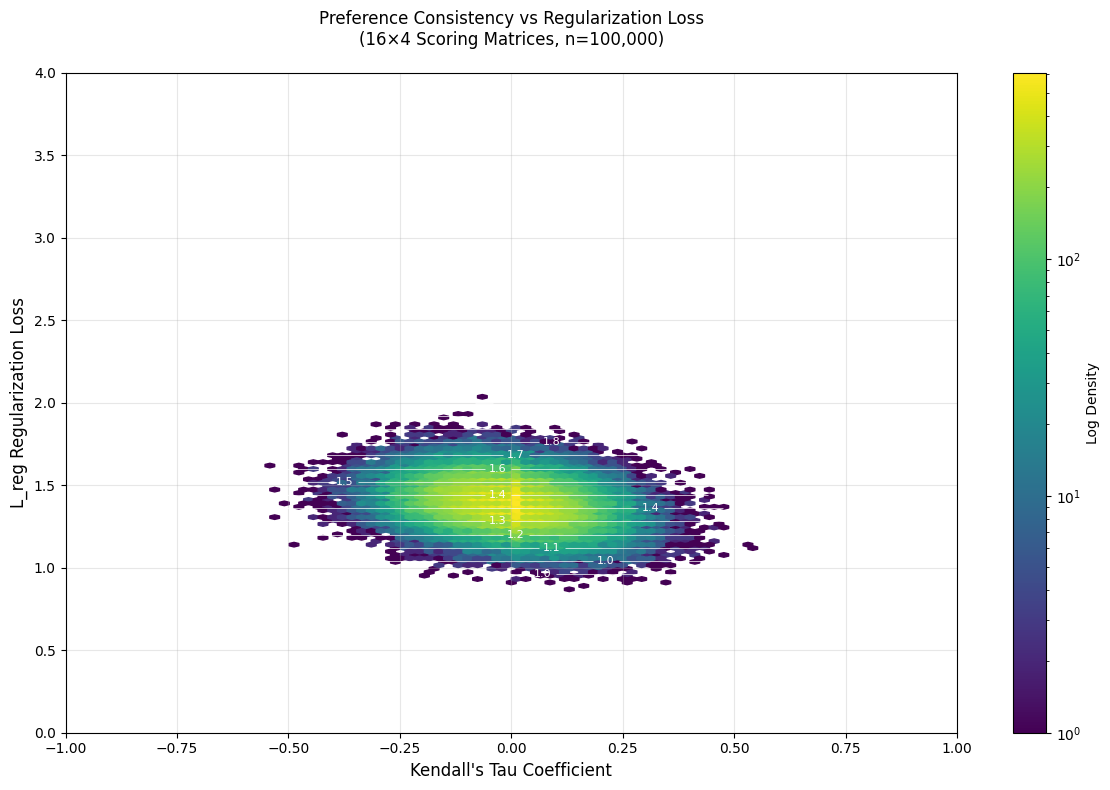

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau
from tqdm import tqdm

# 生成固定全局矩阵 (16x4)
torch.manual_seed(42)
base_global = torch.randint(1, 6, (16, 4)).float()

# 高效采样函数
def generate_batch(batch_size=1024):
    """生成批量随机评分矩阵"""
    return torch.randint(1, 6, (batch_size, 16, 4)).float()

# 向量化Kendall's Tau计算 (使用GPU加速)
def batch_kendall_tau(local_batch, global_mat):
    """批量计算Kendall's Tau系数"""
    local_np = local_batch.cpu().numpy()
    global_np = global_mat.cpu().numpy()
    tau_values = []
    
    for b in range(local_np.shape[0]):
        batch_taus = []
        for i in range(16):
            local_rank = np.argsort(-local_np[b, i])
            global_rank = np.argsort(-global_np[i])
            tau, _ = kendalltau(local_rank, global_rank)
            batch_taus.append(tau if not np.isnan(tau) else 0.0)
        tau_values.append(np.mean(batch_taus))
    
    return np.array(tau_values)

# 生成10万个样本
num_samples = 100000
batch_size = 1024
results = []

with tqdm(total=num_samples, desc="Generating samples") as pbar:
    for _ in range(0, num_samples, batch_size):
        local_batch = generate_batch(batch_size)
        
        # 计算L_reg
        l_reg_batch = torch.stack([
            compute_l_reg(local, base_global)
            for local in local_batch
        ]).cpu().numpy()
        
        # 计算Kendall's Tau
        tau_batch = batch_kendall_tau(local_batch, base_global)
        
        # 保存结果
        results.extend(zip(tau_batch, l_reg_batch))
        pbar.update(batch_size)

# 转换为numpy数组
results = np.array(results)

# 可视化
plt.figure(figsize=(12, 8))
hexbin = plt.hexbin(results[:,0], results[:,1], 
                   gridsize=50, cmap='viridis', 
                   mincnt=1, bins='log')

# 添加趋势面
from scipy.interpolate import griddata

# 生成网格
xi = np.linspace(-1, 1, 100)
yi = np.linspace(0, 4, 100)
zi = griddata(results, results[:,1], (xi[None,:], yi[:,None]), method='cubic')

# 绘制趋势面
contour = plt.contour(xi, yi, zi, levels=15, linewidths=0.5, colors='white')
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

plt.colorbar(hexbin, label='Log Density')
plt.xlabel("Kendall's Tau Coefficient", fontsize=12)
plt.ylabel('L_reg Regularization Loss', fontsize=12)
plt.title('Preference Consistency vs Regularization Loss\n(16×4 Scoring Matrices, n=100,000)', pad=20)
plt.grid(alpha=0.3)
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

## 查看ranking loss与 kendall's tau的关系

In [12]:
from typing import List
def scores_to_ranks(scores: List[List[float]]) -> torch.Tensor:
    """
    将分数转换为排名。相同分数时，位置靠前的排名更高。
    
    Args:
        scores: 二维列表，每个子列表包含一组分数
        
    Returns:
        包含排名的tensor
    """
    ranks = []
    for score_group in scores:
        # 创建(分数, 位置)对的列表
        score_pos_pairs = [(score, idx) for idx, score in enumerate(score_group)]
        # 首先按分数降序排序，分数相同时按位置升序排序
        sorted_pairs = sorted(score_pos_pairs, key=lambda x: (-x[0], x[1]))
        # 创建排名映射
        rank_map = {pos: rank + 1 for rank, (_, pos) in enumerate(sorted_pairs)}
        # 按原始顺序获取排名
        group_ranks = [rank_map[i] for i in range(len(score_group))]
        ranks.append(group_ranks)
    
    return torch.tensor(ranks, dtype=torch.float32)

def ranknet_loss(scores1: List[List[float]], scores2: List[List[float]]) -> torch.Tensor:
    """
    计算RankNet Loss。
    
    Args:
        scores1: 第一个模型的分数
        scores2: 第二个模型的分数
        
    Returns:
        RankNet Loss值
    """
    # 将分数转换为排名
    ranks1 = scores_to_ranks(scores1)
    ranks2 = scores_to_ranks(scores2)
    
    batch_size, num_responses = ranks1.shape
    
    # 计算所有可能的响应对之间的排名差异
    total_loss = torch.tensor(0.0, requires_grad=False)
    
    for i in range(batch_size):
        for j in range(num_responses):
            for k in range(j + 1, num_responses):
                # 计算排名差异
                rank_diff1 = ranks1[i][j] - ranks1[i][k]
                rank_diff2 = ranks2[i][j] - ranks2[i][k]
                
                # 如果两个模型对排序有不同的判断
                if torch.sign(rank_diff1) != torch.sign(rank_diff2):
                    # 使用 sigmoid 函数计算概率
                    prob = 1 / (1 + torch.exp(-rank_diff1))
                    # 计算交叉熵损失
                    loss = -torch.log(prob) if rank_diff2 < 0 else -torch.log(1 - prob)
                    total_loss = total_loss + loss

    # 归一化损失
    num_pairs = batch_size * (num_responses * (num_responses - 1)) / 2
    return total_loss / num_pairs

Generating samples: 10240it [01:40, 102.39it/s]                          


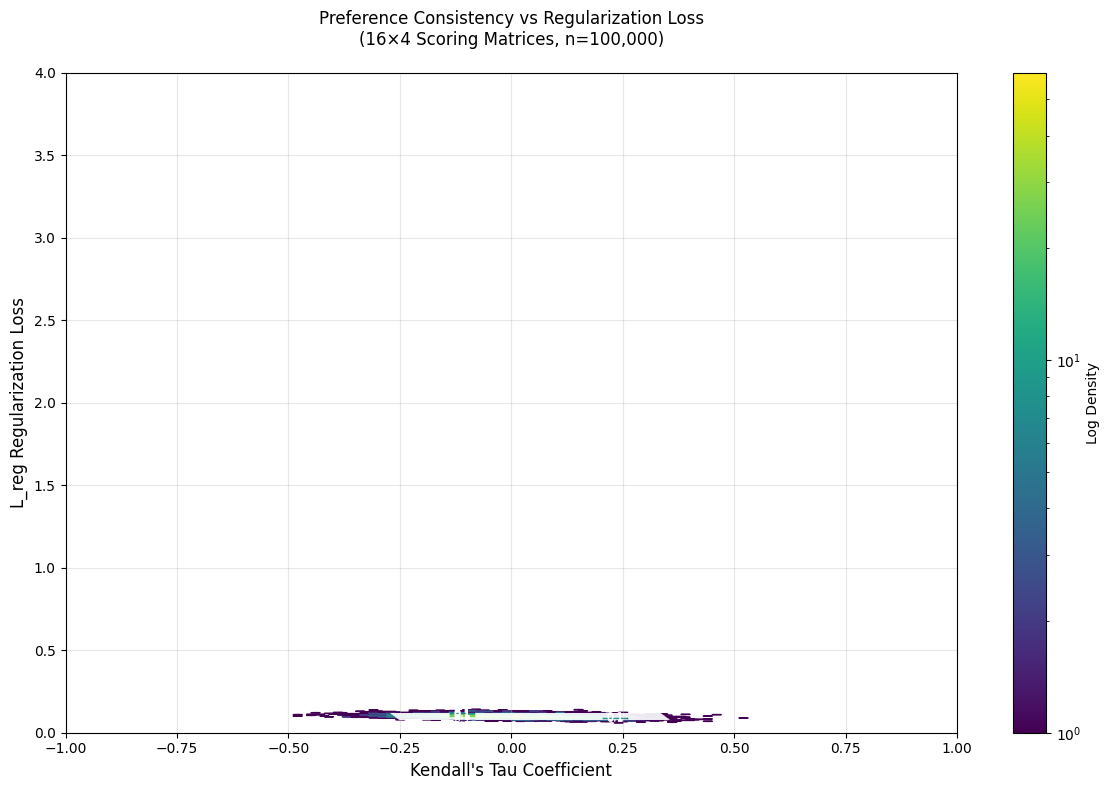

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau
from tqdm import tqdm

# 生成固定全局矩阵 (16x4)
torch.manual_seed(42)
base_global = torch.randint(1, 6, (16, 4)).float()

# 高效采样函数
def generate_batch(batch_size=1024):
    """生成批量随机评分矩阵"""
    return torch.randint(1, 6, (batch_size, 16, 4)).float()

# 向量化Kendall's Tau计算 (使用GPU加速)
def batch_kendall_tau(local_batch, global_mat):
    """批量计算Kendall's Tau系数"""
    local_np = local_batch.cpu().numpy()
    global_np = global_mat.cpu().numpy()
    tau_values = []
    
    for b in range(local_np.shape[0]):
        batch_taus = []
        for i in range(16):
            local_rank = np.argsort(-local_np[b, i])
            global_rank = np.argsort(-global_np[i])
            tau, _ = kendalltau(local_rank, global_rank)
            batch_taus.append(tau if not np.isnan(tau) else 0.0)
        tau_values.append(np.mean(batch_taus))
    
    return np.array(tau_values)

# 生成10万个样本
num_samples = 10000
batch_size = 1024
results = []

with tqdm(total=num_samples, desc="Generating samples") as pbar:
    for _ in range(0, num_samples, batch_size):
        local_batch = generate_batch(batch_size)
        
        # 计算L_reg
        l_reg_batch = torch.stack([
            ranknet_loss(local, base_global)
            for local in local_batch
        ]).cpu().numpy()
        
        # 计算Kendall's Tau
        tau_batch = batch_kendall_tau(local_batch, base_global)
        
        # 保存结果
        results.extend(zip(tau_batch, l_reg_batch))
        pbar.update(batch_size)

# 转换为numpy数组
results = np.array(results)

# 可视化
plt.figure(figsize=(12, 8))
hexbin = plt.hexbin(results[:,0], results[:,1], 
                   gridsize=50, cmap='viridis', 
                   mincnt=1, bins='log')

# 添加趋势面
from scipy.interpolate import griddata

# 生成网格
xi = np.linspace(-1, 1, 100)
yi = np.linspace(0, 0.5, 100)
zi = griddata(results, results[:,1], (xi[None,:], yi[:,None]), method='cubic')

# 绘制趋势面
contour = plt.contour(xi, yi, zi, levels=15, linewidths=0.5, colors='white')
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

plt.colorbar(hexbin, label='Log Density')
plt.xlabel("Kendall's Tau Coefficient", fontsize=12)
plt.ylabel('L_reg Regularization Loss', fontsize=12)
plt.title('Preference Consistency vs Regularization Loss\n(16×4 Scoring Matrices, n=100,000)', pad=20)
plt.grid(alpha=0.3)
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

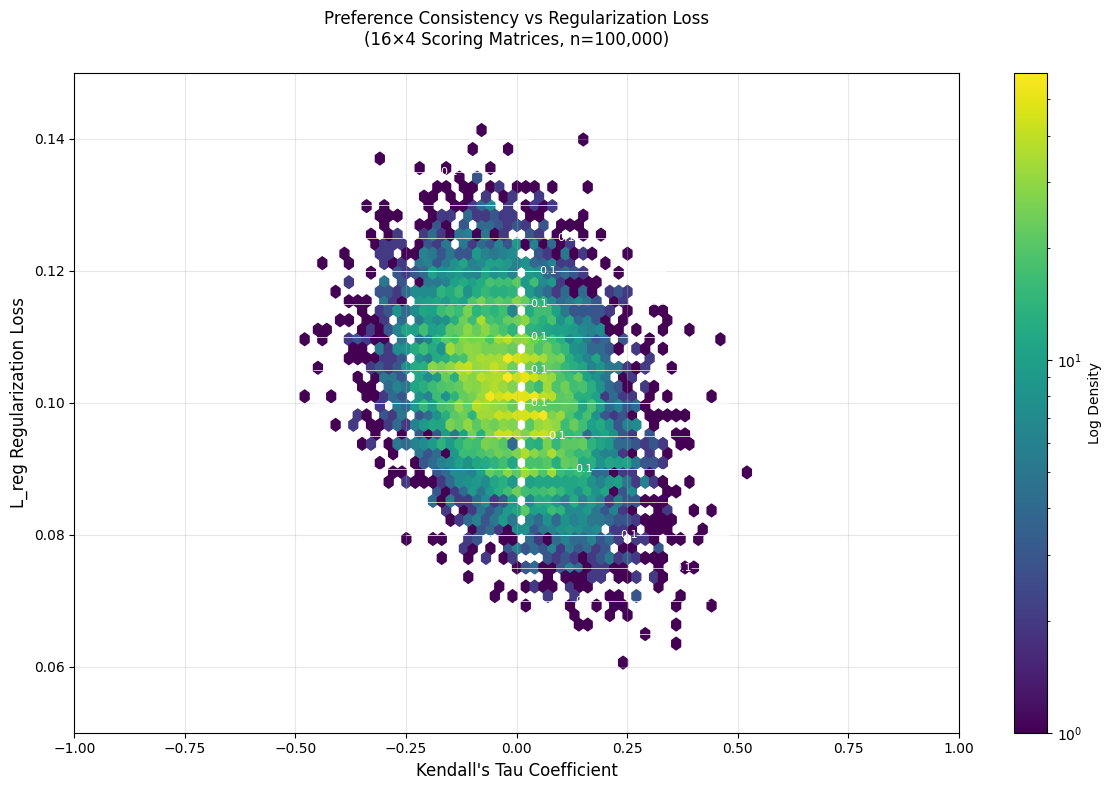

In [21]:
# 可视化
plt.figure(figsize=(12, 8))
hexbin = plt.hexbin(results[:,0], results[:,1], 
                   gridsize=50, cmap='viridis', 
                   mincnt=1, bins='log')

# 添加趋势面
from scipy.interpolate import griddata

# 生成网格
xi = np.linspace(-0.5, 0.5, 50)
yi = np.linspace(0.05, 0.15, 100)
zi = griddata(results, results[:,1], (xi[None,:], yi[:,None]), method='cubic')

# 绘制趋势面
contour = plt.contour(xi, yi, zi, levels=15, linewidths=0.5, colors='white')
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

plt.colorbar(hexbin, label='Log Density')
plt.xlabel("Kendall's Tau Coefficient", fontsize=12)
plt.ylabel('L_reg Regularization Loss', fontsize=12)
plt.title('Preference Consistency vs Regularization Loss\n(16×4 Scoring Matrices, n=100,000)', pad=20)
plt.grid(alpha=0.3)
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()